# Compare uptake curves

In [1]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

## Configuration

In [2]:
colors = {
    "JP10": "#d4b9da", "JP7": "#df65b0", "JP8": "#980043",
    "VI10": "#A8E6A3", "VI7": "#4CAF50", "VI8": "#1B5E20",
    "BC10": "#A7C7E7", "BC7": "#2196F3", "BC8": "#0D47A1",
    "EC10": "#FFD580", "EC7": "#FFA500", "EC8": "#CC5500",
}

scenarios = {
    "dor": {
        "base_dir": "roms_marbl_dic",
        "ctrl_subdir": "OUTPUT_dor",
        "title": "DOR",
        "exps": {
            "JP10": {"label": r"\mathrm{J10}\!\ominus"},
            "JP7":  {"label": r"\mathrm{J100}\!\ominus"},
            "JP8":  {"label": r"\mathrm{J1000}\!\ominus"},
            "VI10": {"label": r"\mathrm{V10}\!\ominus"},
            "VI7":  {"label": r"\mathrm{V100}\!\ominus"},
            "VI8":  {"label": r"\mathrm{V1000}\!\ominus"},
            "BC10": {"label": r"\mathrm{B10}\!\ominus"},
            "BC7":  {"label": r"\mathrm{B100}\!\ominus"},
            "BC8":  {"label": r"\mathrm{B1000}\!\ominus"},
            "EC10": {"label": r"\mathrm{E10}\!\ominus"},
            "EC7":  {"label": r"\mathrm{E100}\!\ominus"},
            "EC8":  {"label": r"\mathrm{E1000}\!\ominus"},
        },
    },
    "oae": {
        "base_dir": "roms_marbl_alk",
        "ctrl_subdir": "OUTPUT_oae",
        "title": "OAE",
        "exps": {
            "JP10": {"label": r"\mathrm{J10}\!\oplus"},
            "JP7":  {"label": r"\mathrm{J100}\!\oplus"},
            "JP8":  {"label": r"\mathrm{J1000}\!\oplus"},
            "VI10": {"label": r"\mathrm{V10}\!\oplus"},
            "VI7":  {"label": r"\mathrm{V100}\!\oplus"},
            "VI8":  {"label": r"\mathrm{V1000}\!\oplus"},
            "BC10": {"label": r"\mathrm{B10}\!\oplus"},
            "BC7":  {"label": r"\mathrm{B100}\!\oplus"},
            "BC8":  {"label": r"\mathrm{B1000}\!\oplus"},
            "EC10": {"label": r"\mathrm{E10}\!\oplus"},
            "EC7":  {"label": r"\mathrm{E100}\!\oplus"},
            "EC8":  {"label": r"\mathrm{E1000}\!\oplus"},
        },
    },
}

for scen in scenarios.values():
    for exp in scen["exps"]:
        scen["exps"][exp]["color"] = colors[exp]

## Load data

In [3]:
kwargs = {"combine": "nested", "concat_dim": "time"}

def _exp_dir(base_dir, exp):
    return f"exp{exp}"

for scen in scenarios.values():
    base_dir = scen["base_dir"]
    scen["outputs"] = {}
    for exp in scen["exps"]:
        exp_dir = _exp_dir(base_dir, exp)
        ds_2000 = xr.open_mfdataset(
            f"{base_dir}/{exp_dir}/OUTPUT/INTEGRATED/integrated.2000*.nc", **kwargs
        )
        ds_2001 = xr.open_mfdataset(
            f"{base_dir}/{exp_dir}/OUTPUT/INTEGRATED/integrated.2001*.nc", **kwargs
        )
        ds = xr.concat([ds_2000, ds_2001], dim="time")
        if "abs_time" in ds:
            ds = ds.swap_dims({"time": "abs_time"}).rename({"abs_time": "time"})
        scen["outputs"][exp] = ds

    ds_ctrl = xr.open_mfdataset(
        f"roms/exp0/{scen['ctrl_subdir']}/INTEGRATED/integrated.*.nc", **kwargs
    )
    if "abs_time" in ds_ctrl:
        ds_ctrl = ds_ctrl.rename({"abs_time": "time"})
    
    scen["ctrl"] = ds_ctrl

/tmp/ipykernel_2176629/853959206.py:26: UserWarning: rename 'abs_time' to 'time' does not create an index anymore. Try using swap_dims instead or use set_index after rename to create an indexed coordinate.
  ds_ctrl = ds_ctrl.rename({"abs_time": "time"})


## Efficiency computation

In [4]:
def eta_truth(ds, scenario_key):
    ratio = ds["deltaDIC"] / ds["c_conserved"].where(ds["c_conserved"] != 0)
    if scenario_key == "dor":
        return 1 - ratio
    else:
        return ratio

def eta_deficit(ds_ctrl, exp, scenario_key):
    conserved = ds_ctrl[f"{exp}_conserved"].where(ds_ctrl[f"{exp}_conserved"] != 0)
    if scenario_key == "dor":
        return 1 - ds_ctrl[f"{exp}_deficit"] / conserved
    else:
        return ds_ctrl[f"{exp}_oae_def"] / conserved

## Plotting

In [5]:
BACKGROUND_COLOR = "#f5f5f5"
VLINE_DATE = np.datetime64("2000-02-01")


def add_date_vline(ax, date=VLINE_DATE):
    ax.axvline(date, color="k", linestyle="--", linewidth=1)

In [6]:
def plot_efficiency_curves(ax, exp_pref_list, scen, scenario_key, amps=("10", "7", "8"), legend_below=True, ymin=False, ymax=False, enum="(a)", show_deficit_ref=True):
    exps = scen["exps"]
    outputs = scen["outputs"]
    ds_ctrl = scen["ctrl"]
    linestyles = ["dashed", "dotted", "dashdot", "solid"]
    ls_idx = 0

    for exp_pref in exp_pref_list:
        for amp in amps:
            exp = f"{exp_pref}{amp}"

            if show_deficit_ref and amp == amps[0]:
                eta = eta_deficit(ds_ctrl, exp, scenario_key)
                label = exps[exp]["label"]
                ax.plot(
                    ds_ctrl.time, eta, color="k",
                    label=rf"$\tilde{{\mathcal{{E}}}}_{{{label}}}$",
                    linewidth=4, linestyle=linestyles[ls_idx],
                )
                ls_idx += 1

            ds = outputs[exp]
            eta = eta_truth(ds, scenario_key)
            label = exps[exp]["label"]
            ax.plot(
                ds.time, eta, color=exps[exp]["color"],
                label=rf"$\mathcal{{E}}_{{{label}}}$",
                linewidth=2,
            )

    ax.set_xticks(ax.get_xticks()[::2])
    ax.set_xlabel("Time")
    ax.set_title(rf"{enum} {scen['title']} efficiency")
    ax.grid()
    add_date_vline(ax)
    ax.patch.set_facecolor(BACKGROUND_COLOR)
    if ymin is not False or ymax is not False:
        bottom, top = ax.get_ylim()
        ax.set_ylim(
            bottom if ymin is False else ymin,
            top if ymax is False else ymax,
        )
    if legend_below:
        ax.legend(
            loc="upper center", bbox_to_anchor=(0.5, -0.2),
            ncol=len(exp_pref_list), facecolor=BACKGROUND_COLOR, fontsize=12,
        )
    else:
        ax.legend(loc="lower right", ncol=len(exp_pref_list),
                  facecolor=BACKGROUND_COLOR, fontsize=12)

In [7]:
def _plot_efficiency_diff(ax, exp_pref_list, scen, scenario_key, amps,
                          eta_ref_fn, ref_label_fn, enum, relative, abs_label="Absolute error", rel_label="Relative error", title_suffix="",
                          relative_denom="ref", denom_label="", amps_to_plot=None):
    """Shared logic for difference/error panels.

    eta_ref_fn(exp_ref) -> reference eta DataArray for the given reference experiment
    ref_label_fn(label) -> LaTeX string wrapping the reference experiment's plain label
    relative_denom -> "ref" for (REF-TRUE)/REF (default) or "true" for (REF-TRUE)/TRUE
    amps_to_plot -> subset of amps to plot (default: all of amps); amps[0] is always the reference
    """
    exps = scen["exps"]
    outputs = scen["outputs"]
    _amps_to_plot = amps_to_plot if amps_to_plot is not None else amps

    for exp_pref in exp_pref_list:
        exp_ref = f"{exp_pref}{amps[0]}"
        eta_ref = eta_ref_fn(exp_ref)
        ref_label = ref_label_fn(exps[exp_ref]["label"])

        for amp in _amps_to_plot:
            exp = f"{exp_pref}{amp}"
            ds = outputs[exp]
            eta = eta_truth(ds, scenario_key)

            n = min(eta_ref.sizes["time"], eta.sizes["time"])
            eta_ref_n = eta_ref.isel(time=slice(0, n))
            eta_n = eta.isel(time=slice(0, n))
            diff = eta_ref_n - eta_n
            if relative:
                denom = eta_ref_n if relative_denom == "ref" else eta_n
                diff = 100 * diff / denom.where(denom != 0)

            label = rf"\mathcal{{E}}_{{{exps[exp]['label']}}}"
            if relative:
                denom_str = ref_label if relative_denom == "ref" else label
                plot_label = rf"$({ref_label}-{label})/{denom_str}$"
            else:
                plot_label = rf"${ref_label}-{label}$"
            ax.plot(
                ds.time.isel(time=slice(0, n)), diff, color=exps[exp]["color"],
                label=plot_label, linewidth=2,
            )

    ax.set_xticks(ax.get_xticks()[::2])
    ax.set_xlabel("Time")
    if relative:
        ax.set_ylabel("%")
        denom_desc = "" if relative_denom == "ref" else denom_label
        ax.set_title(rf"{enum} {rel_label} in {scen['title']} efficiencies{title_suffix}{denom_desc}")
    else:
        ax.set_title(rf"{enum} {abs_label} in {scen['title']} efficiencies{title_suffix}")
    ax.grid()
    ax.axhline(y=0, color='black', linestyle='-', linewidth=1)
    add_date_vline(ax)

    ax.legend(
        loc="upper center", bbox_to_anchor=(0.5, -0.2),
        ncol=max(1, len(exp_pref_list) // 2), facecolor=BACKGROUND_COLOR, fontsize=12,
    )
    ax.patch.set_facecolor(BACKGROUND_COLOR)


def plot_efficiency_curves_diff(ax, exp_pref_list, scen, scenario_key, amps=("10", "7", "8"), enum="(b)", relative=False, relative_denom="true", amps_to_plot=None):
    ds_ctrl = scen["ctrl"]
    _plot_efficiency_diff(
        ax, exp_pref_list, scen, scenario_key, amps,
        eta_ref_fn=lambda exp_ref: eta_deficit(ds_ctrl, exp_ref, scenario_key),
        ref_label_fn=lambda label: rf"\tilde{{\mathcal{{E}}}}_{{{label}}}",
        enum=enum, relative=relative, abs_label="Absolute error", rel_label="Relative error", relative_denom=relative_denom, denom_label=" (rel. to truth)",
        amps_to_plot=amps_to_plot,
    )

def plot_efficiency_curves_diff_vs_smallest_amp(ax, exp_pref_list, scen, scenario_key, amps=("7", "8"), enum="(b)", relative=False, relative_denom="true"):
    outputs = scen["outputs"]
    _plot_efficiency_diff(
        ax, exp_pref_list, scen, scenario_key, amps=("10",) + tuple(amps), amps_to_plot=amps,
        eta_ref_fn=lambda exp_ref: eta_truth(outputs[exp_ref], scenario_key),
        ref_label_fn=lambda label: rf"\mathcal{{E}}_{{{label}}}",
        enum=enum, relative=relative, abs_label="Absolute difference", rel_label="Relative difference", relative_denom=relative_denom, denom_label=" (rel. to smallest ampl. exp)"
    )

## Combined 2×2 figure: curves + absolute OAE error & relative OAE error ($\mathcal{E}$ vs. $\tilde{\mathcal{E}}$)

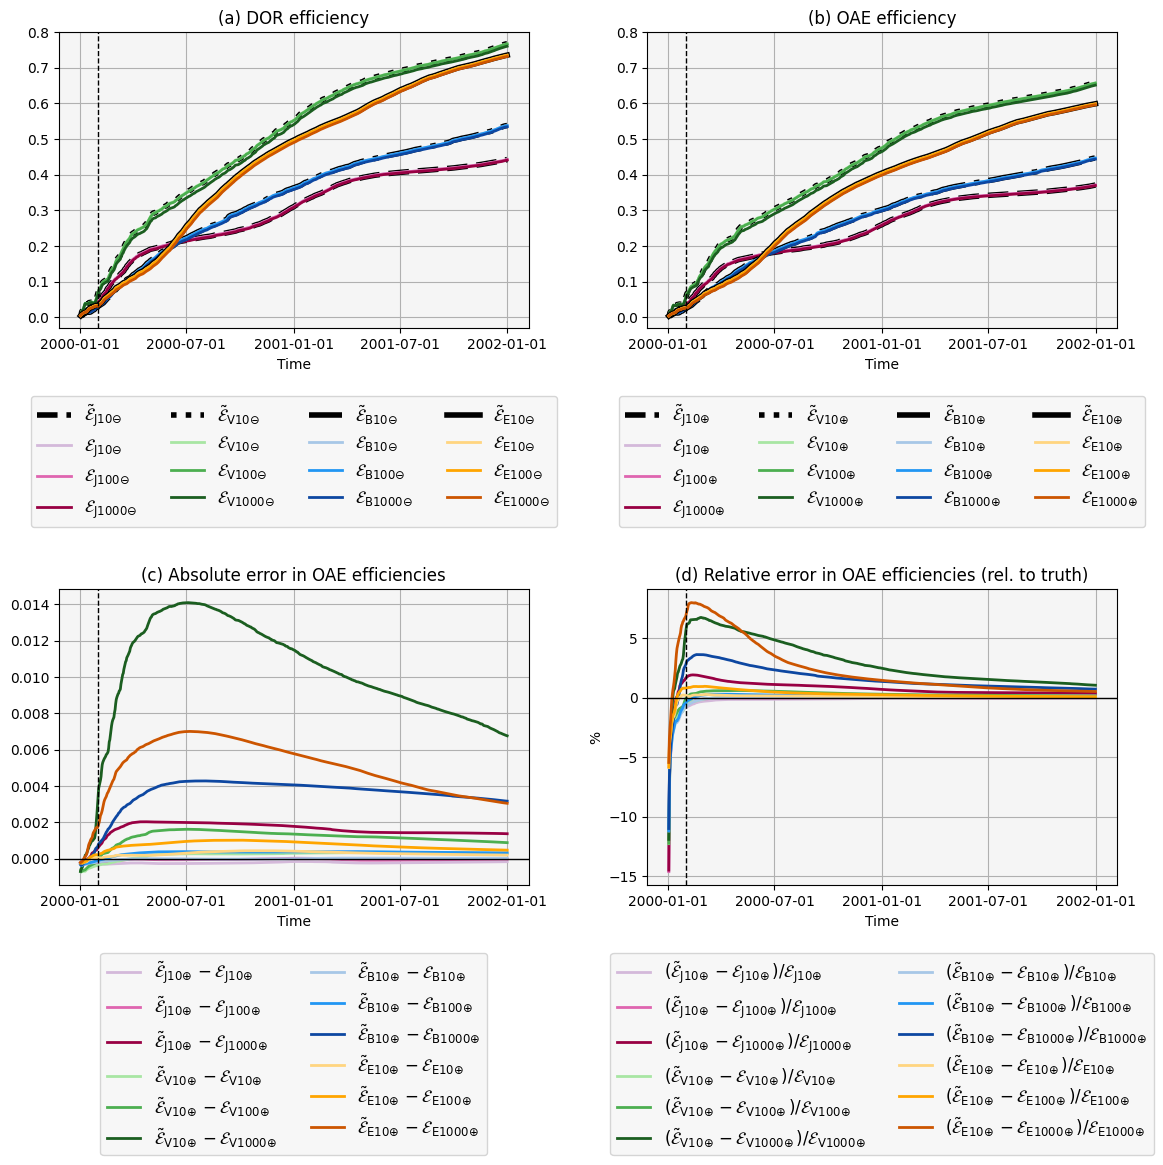

In [8]:
fig, axs = plt.subplots(2, 2, figsize=(12, 12))

enum_list = ["(a)", "(b)"]
for j, key in enumerate(scenarios):
    scen = scenarios[key]
    plot_efficiency_curves(axs[0, j], ["JP", "VI", "BC", "EC"], scen, key, enum=enum_list[j], ymin=-0.03, ymax=0.8)
    
plot_efficiency_curves_diff(axs[1, 0], ["JP", "VI", "BC", "EC"], scenarios["oae"], "oae", enum="(c)", relative=False)
plot_efficiency_curves_diff(axs[1, 1], ["JP", "VI", "BC", "EC"], scenarios["oae"], "oae", enum="(d)", relative=True)

plt.tight_layout()

In [16]:
fig.savefig("figures/curves_oae_e_vs_etilde.png", dpi=300, bbox_inches="tight")

## Combined 3×2 figure: curves + absolute + relative error ($\mathcal{E}$ vs. $\tilde{\mathcal{E}}$)

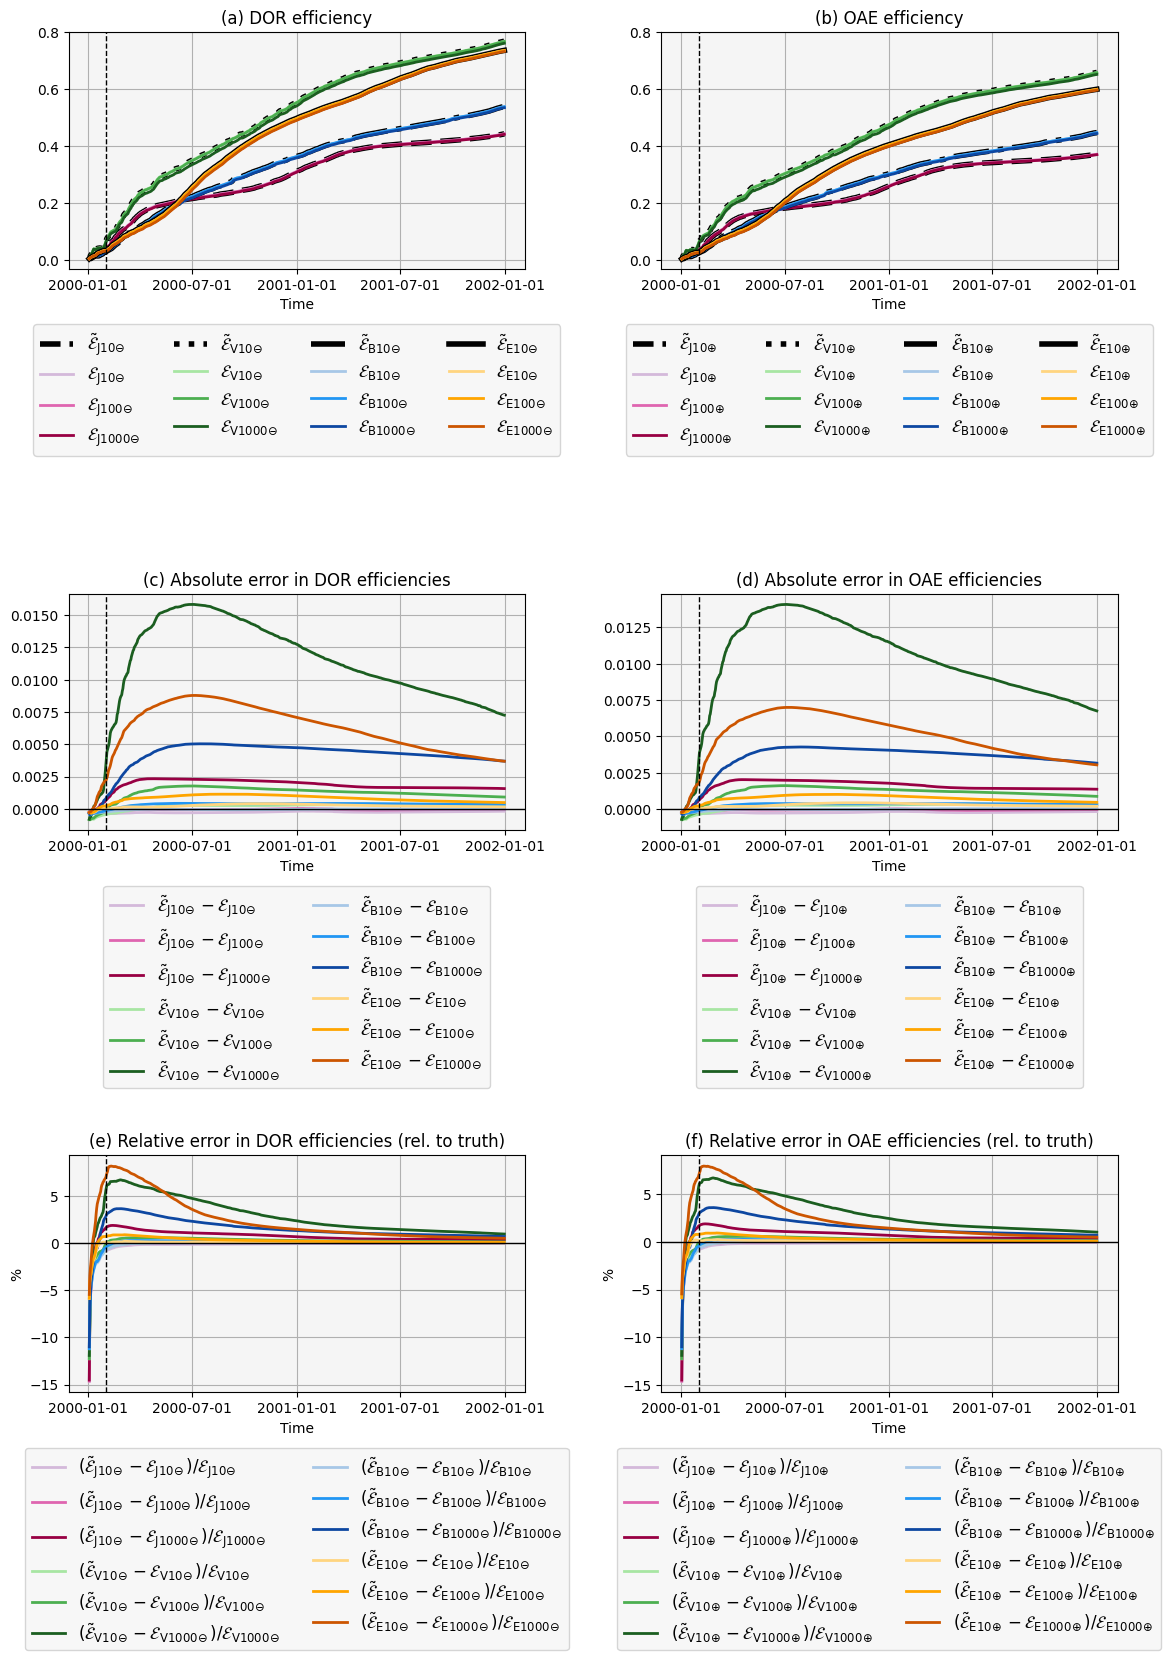

In [18]:
fig, axs = plt.subplots(3, 2, figsize=(12, 17))

enum_list = [["(a)", "(b)"], ["(c)", "(d)"], ["(e)", "(f)"]]
for j, key in enumerate(scenarios):
    scen = scenarios[key]
    plot_efficiency_curves(axs[0, j], ["JP", "VI", "BC", "EC"], scen, key, enum=enum_list[0][j], ymin=-0.03, ymax=0.8)
    plot_efficiency_curves_diff(axs[1, j], ["JP", "VI", "BC", "EC"], scen, key, enum=enum_list[1][j], relative=False)
    plot_efficiency_curves_diff(axs[2, j], ["JP", "VI", "BC", "EC"], scen, key, enum=enum_list[2][j], relative=True)

plt.tight_layout()

In [19]:
fig.savefig("figures/curves_combined_e_vs_etilde.png", dpi=300, bbox_inches="tight")

## Combined 3×2 figure: curves + absolute + relative error (vs. smallest amplitude)

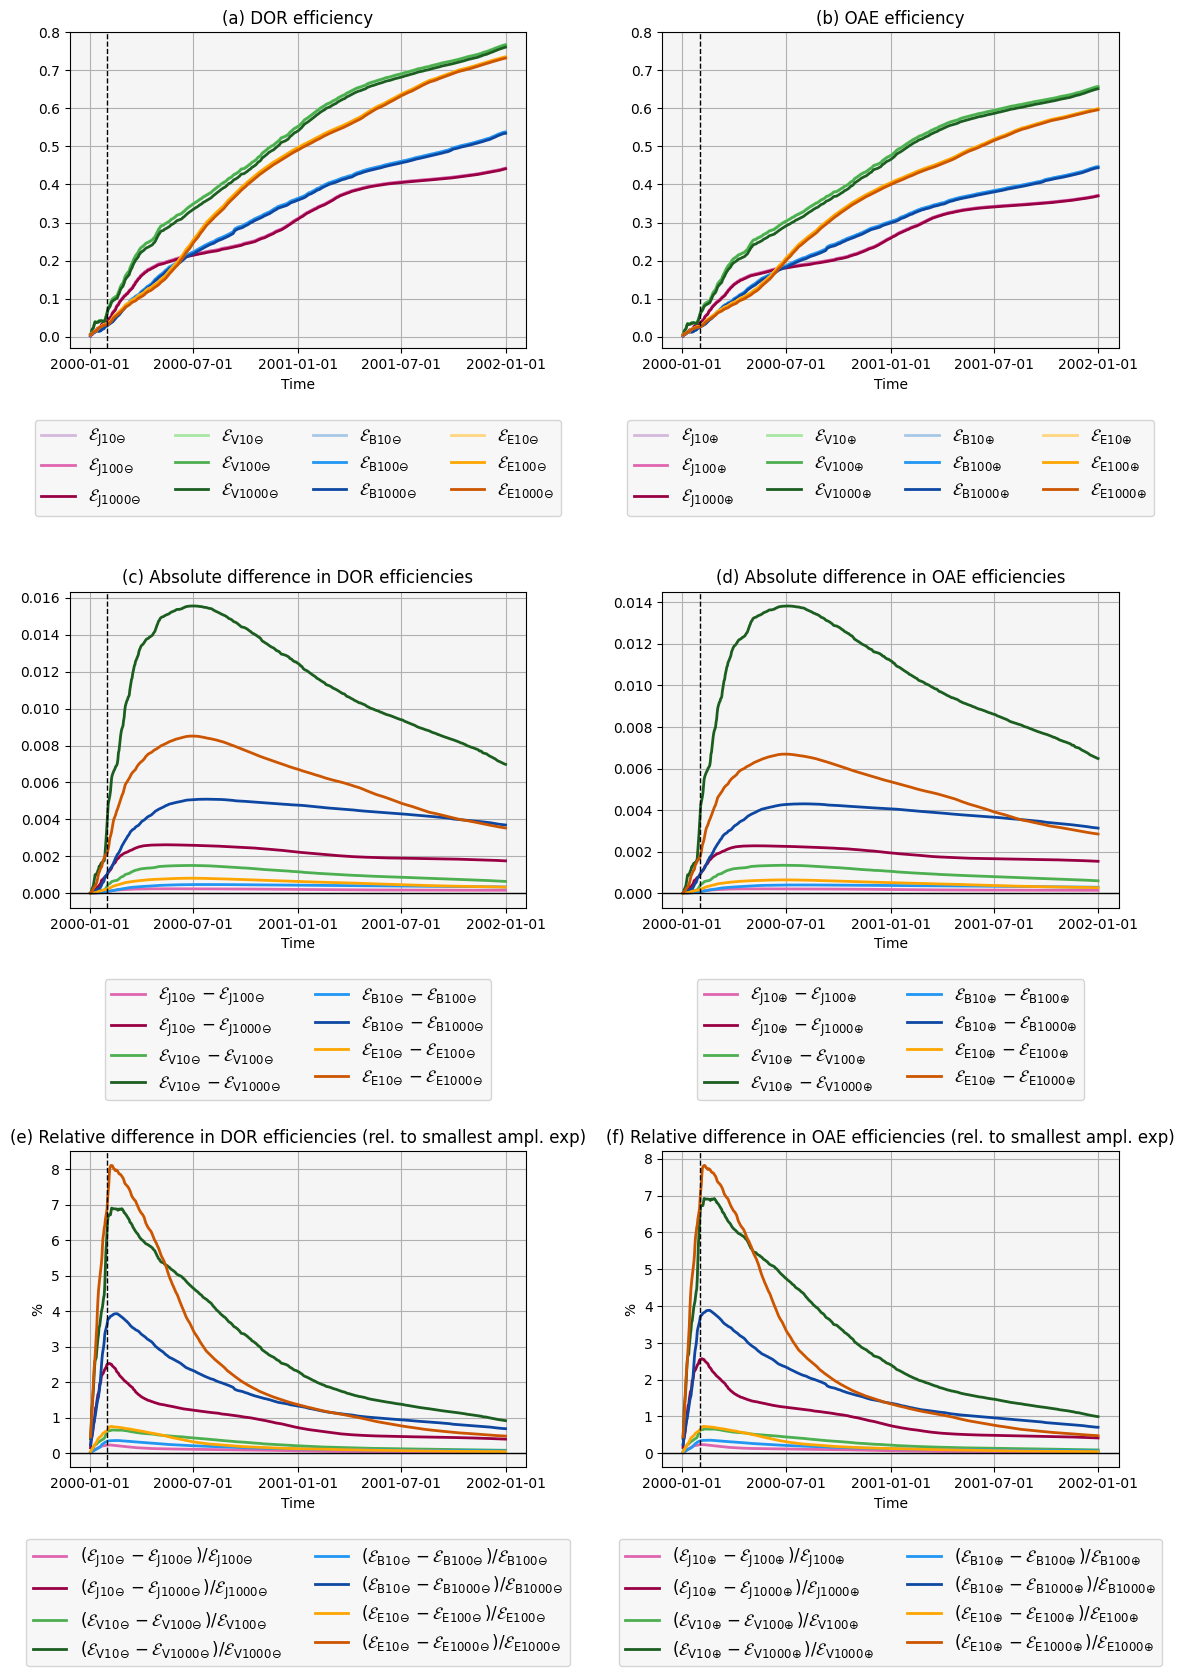

In [28]:
fig, axs = plt.subplots(3, 2, figsize=(12, 17))

enum_list = [["(a)", "(b)"], ["(c)", "(d)"], ["(e)", "(f)"]]
for j, key in enumerate(scenarios):
    scen = scenarios[key]
    plot_efficiency_curves(axs[0, j], ["JP", "VI", "BC", "EC"], scen, key, enum=enum_list[0][j], show_deficit_ref=False, ymin=-0.03, ymax=0.8)
    plot_efficiency_curves_diff_vs_smallest_amp(axs[1, j], ["JP", "VI", "BC", "EC"], scen, key, enum=enum_list[1][j], relative=False)
    plot_efficiency_curves_diff_vs_smallest_amp(axs[2, j], ["JP", "VI", "BC", "EC"], scen, key, enum=enum_list[2][j], relative=True)

plt.tight_layout()

In [29]:
fig.savefig("figures/curves_combined_vs_smallest_amplitude.png", dpi=300, bbox_inches="tight")

## Relative error: normalized by REF vs. by TRUE ($\mathcal{E}$ vs. $\tilde{\mathcal{E}}$, DOR)

Left: $(\mathcal{E}-\tilde{\mathcal{E}})/\tilde{\mathcal{E}}$. Right: $(\mathcal{E}-\tilde{\mathcal{E}})/\mathcal{E}$.

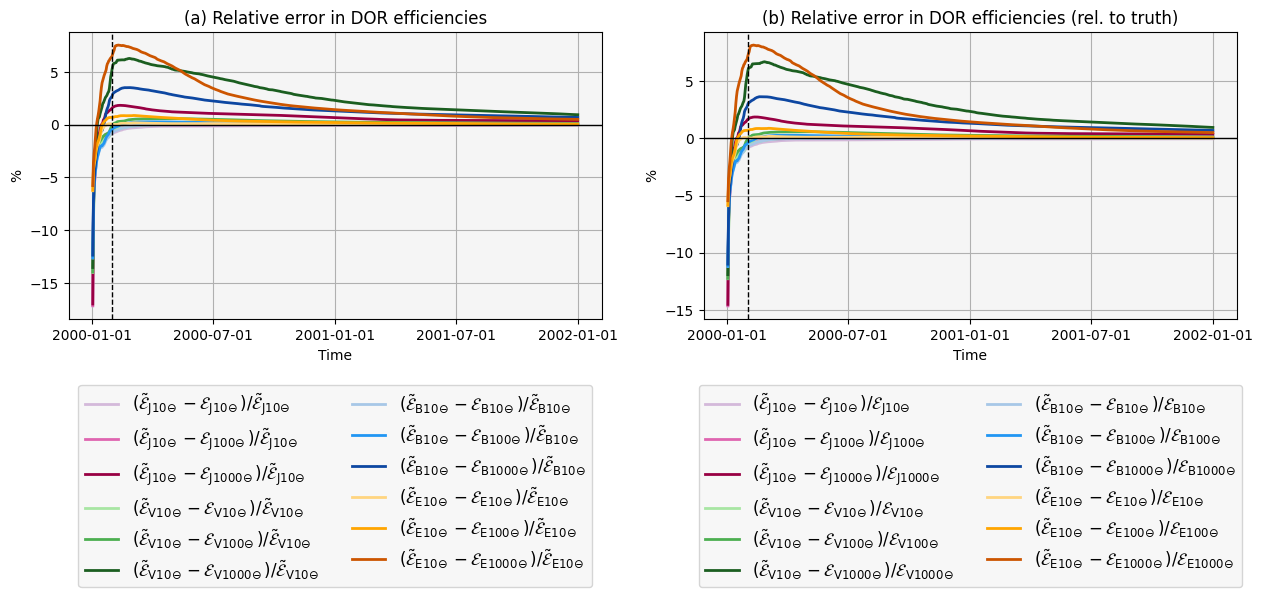

In [31]:
scen = scenarios["dor"]
fig, axs = plt.subplots(1, 2, figsize=(13, 6.5))
plot_efficiency_curves_diff(axs[0], ["JP", "VI", "BC", "EC"], scen, "dor", enum="(a)", relative=True, relative_denom="ref")
plot_efficiency_curves_diff(axs[1], ["JP", "VI", "BC", "EC"], scen, "dor", enum="(b)", relative=True, relative_denom="true")
plt.tight_layout()

## Total uptake

Conversion factor:
$$
1 \text{ mmol} = 10^{-3} \text{ mol}
$$
Mass of CO2 per mole: 44 g/mol

Mass of 1 mmol:
$$
    10^{-3} \cdot 44\text{ g} = 4.4 \cdot 10^{-2}\text{ g} = 4.4 \cdot 10^{-11}\text{ kt}
$$

In [32]:
def plot_uptake_curves(ax, amp, scen, scenario_key, enum):
    exps = scen["exps"]
    outputs = scen["outputs"]
    ds_ctrl = scen["ctrl"]
    linestyles = ["solid", "dashed", "dotted", "dashdot"]
    ls_idx = 0

    for exp_pref in ["VI", "BC", "EC", "JP"]:
        exp = f"{exp_pref}{amp}"

        eta_def = eta_deficit(ds_ctrl, exp, scenario_key)
        conserved = ds_ctrl[f"{exp}_conserved"]
        uptake_deficit = eta_def * conserved * 4.4e-11
        label = exps[exp]["label"]
        ax.plot(
            ds_ctrl.time, uptake_deficit, color="gray",
            label=rf"$\tilde{{\mathcal{{U}}}}_{{{label}}}$",
            linewidth=4, linestyle=linestyles[ls_idx],
        )
        ls_idx += 1

        ds = outputs[exp]
        eta = eta_truth(ds, scenario_key)
        uptake = eta * ds["c_conserved"] * 4.4e-11
        if scenario_key == "dor":
            uptake = -1 * uptake
        ax.plot(
            ds.time, uptake, color=exps[exp]["color"],
            label=rf"$\mathcal{{U}}_{{{label}}}$",
            linewidth=2,
        )

    ax.set_xticks(ax.get_xticks()[::2])
    ax.set_xlabel("Time")
    ax.set_ylabel(r"ktCO$_2$")
    ax.set_title(rf"{enum} Total CO$_2$ uptake ({scen['title']})")
    ax.grid()
    add_date_vline(ax)
    ax.legend(
        loc="upper center", bbox_to_anchor=(0.5, -0.15),
        ncol=4, facecolor=BACKGROUND_COLOR,
    )
    ax.patch.set_facecolor(BACKGROUND_COLOR)

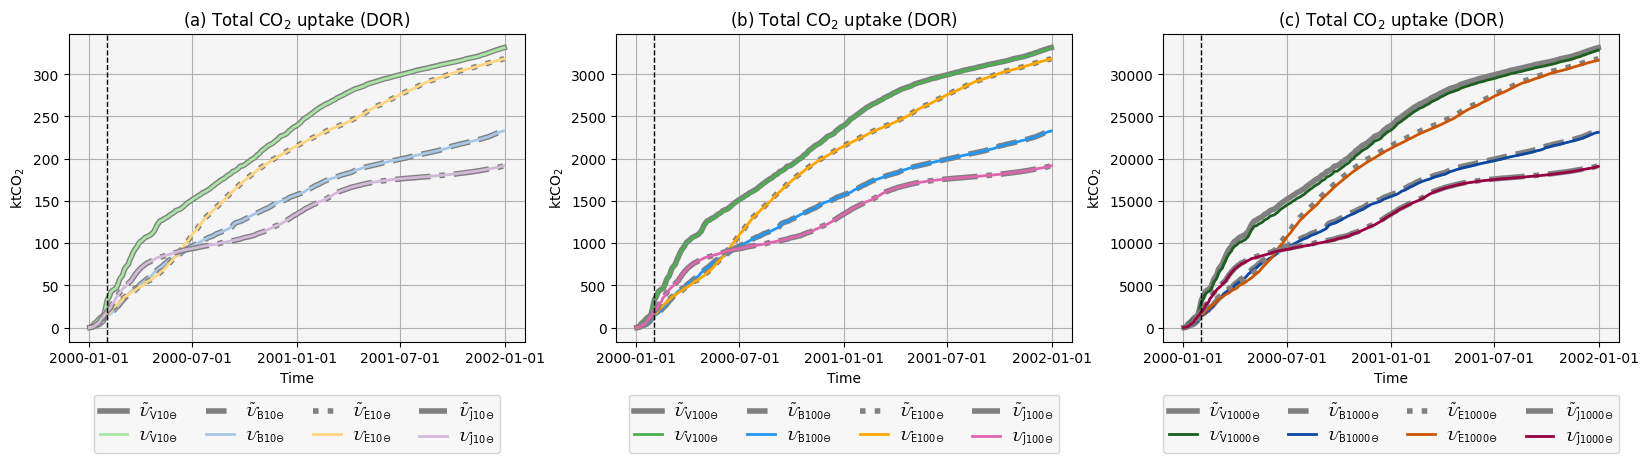

In [33]:
enum_list = ["(a)", "(b)", "(c)"]

fig, axs = plt.subplots(1, 3, figsize=(20, 4))
scen = scenarios["dor"]
for i, amp in enumerate(["10", "7", "8"]):
    plot_uptake_curves(axs[i], amp, scen, "dor", enum_list[i])
fig.subplots_adjust(hspace=0.3)

In [34]:
fig.savefig("figures/total_uptake_dor.png", dpi=300, bbox_inches="tight")

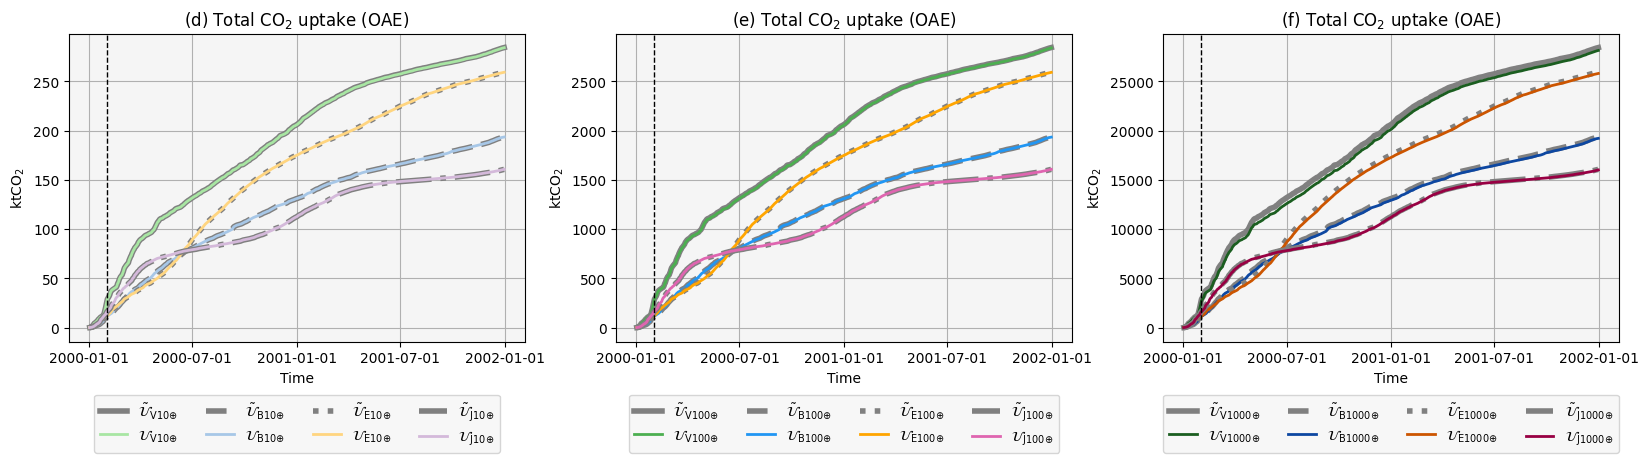

In [35]:
enum_list = ["(d)", "(e)", "(f)"]

fig, axs = plt.subplots(1, 3, figsize=(20, 4))
scen = scenarios["oae"]
for i, amp in enumerate(["10", "7", "8"]):
    plot_uptake_curves(axs[i], amp, scen, "oae", enum_list[i])
fig.subplots_adjust(hspace=0.3)

In [36]:
fig.savefig("figures/total_uptake_oae.png", dpi=300, bbox_inches="tight")

## When occurs maximal difference?

In [23]:
import numpy as np
import pandas as pd

def compute_max_diff(exp_pref, scen, scenario_key, ref="deficit", relative=False, positive_only=False, amp="8"):
    outputs = scen["outputs"]
    ds3 = outputs[f"{exp_pref}{amp}"]

    if ref == "deficit":
        ds_ctrl = scen["ctrl"]
        eta1 = eta_deficit(ds_ctrl, f"{exp_pref}10", scenario_key)
    else:
        ds1 = outputs[f"{exp_pref}10"]
        eta1 = eta_truth(ds1, scenario_key)
        
    eta3 = eta_truth(ds3, scenario_key)

    n = min(eta1.sizes["time"], eta3.sizes["time"])
    eta1_n = eta1.isel(time=slice(0, n))
    eta3_n = eta3.isel(time=slice(0, n))
    diff = eta1_n - eta3_n
    if relative:
        diff = 100 * diff / eta3_n.where(eta3_n != 0)

    diff_vals = diff.values
    if positive_only:
        flat_idx = np.nanargmax(diff_vals)
    else:
        flat_idx = np.nanargmax(np.abs(diff_vals))
    max_idx = np.unravel_index(flat_idx, diff_vals.shape)
    max_diff = diff_vals[max_idx]

    unit = "%" if relative else ""
    print(f"[{scen['title']}] {exp_pref}{amp}: time={max_idx[0]}, date={eta1.time[max_idx].values}, max diff={max_diff:.6f}{unit}")


def compute_diff_at_date(exp_pref, scen, scenario_key, date, ref="deficit", relative=False, amp="8"):
    outputs = scen["outputs"]
    ds3 = outputs[f"{exp_pref}{amp}"]

    if ref == "deficit":
        ds_ctrl = scen["ctrl"]
        eta1 = eta_deficit(ds_ctrl, f"{exp_pref}10", scenario_key)
    else:
        ds1 = outputs[f"{exp_pref}10"]
        eta1 = eta_truth(ds1, scenario_key)

    eta3 = eta_truth(ds3, scenario_key)

    n = min(eta1.sizes["time"], eta3.sizes["time"])
    eta1_n = eta1.isel(time=slice(0, n))
    eta3_n = eta3.isel(time=slice(0, n))
    diff = eta1_n - eta3_n
    if relative:
        diff = 100 * diff / eta3_n.where(eta3_n != 0)

    diff_at = diff.sel(time=pd.Timestamp(date), method="nearest")
    actual_date = diff_at.time.values

    unit = "%" if relative else ""
    print(f"[{scen['title']}] {exp_pref}{amp}: date={actual_date}, diff={float(diff_at):.6f}{unit}")

### largest vs. smallest amplitude

In [25]:
for key in scenarios:
    for pref in ["JP", "VI", "BC", "EC"]:
        compute_max_diff(pref, scenarios[key], key, ref="smallest_ampl")

[DOR] JP8: time=132, date=2000-05-12T11:30:08.000000000, max diff=0.002627
[DOR] VI8: time=183, date=2000-07-02T11:30:08.000000000, max diff=0.015556
[DOR] BC8: time=205, date=2000-07-24T11:30:08.000000000, max diff=0.005095
[DOR] EC8: time=177, date=2000-06-26T11:30:08.000000000, max diff=0.008512
[OAE] JP8: time=132, date=2000-05-12T11:30:08.000000000, max diff=0.002284
[OAE] VI8: time=185, date=2000-07-04T11:30:08.000000000, max diff=0.013817
[OAE] BC8: time=213, date=2000-08-01T11:30:08.000000000, max diff=0.004302
[OAE] EC8: time=177, date=2000-06-26T11:30:08.000000000, max diff=0.006692


In [26]:
for key in scenarios:
    for pref in ["JP", "VI", "BC", "EC"]:
        compute_max_diff(pref, scenarios[key], key, ref="smallest_ampl", relative=True)

[DOR] JP8: time=34, date=2000-02-04T11:30:08.000000000, max diff=2.528888%
[DOR] VI8: time=38, date=2000-02-08T11:30:08.000000000, max diff=6.902831%
[DOR] BC8: time=45, date=2000-02-15T11:30:08.000000000, max diff=3.929150%
[DOR] EC8: time=37, date=2000-02-07T11:30:08.000000000, max diff=8.104686%
[OAE] JP8: time=34, date=2000-02-04T11:30:08.000000000, max diff=2.568321%
[OAE] VI8: time=38, date=2000-02-08T11:30:08.000000000, max diff=6.920937%
[OAE] BC8: time=48, date=2000-02-18T11:30:08.000000000, max diff=3.881890%
[OAE] EC8: time=39, date=2000-02-09T11:30:08.000000000, max diff=7.817724%


### largest amplitude vs. CDR tracer

In [27]:
for key in scenarios:
    for pref in ["JP", "VI", "BC", "EC"]:
        compute_max_diff(pref, scenarios[key], key, ref="deficit")

[DOR] JP8: time=113, date=2000-04-23T11:30:08.000000000, max diff=0.002337
[DOR] VI8: time=183, date=2000-07-02T11:30:08.000000000, max diff=0.015828
[DOR] BC8: time=204, date=2000-07-23T11:30:08.000000000, max diff=0.005039
[DOR] EC8: time=185, date=2000-07-04T11:30:08.000000000, max diff=0.008784
[OAE] JP8: time=106, date=2000-04-16T11:30:08.000000000, max diff=0.002028
[OAE] VI8: time=185, date=2000-07-04T11:30:08.000000000, max diff=0.014085
[OAE] BC8: time=211, date=2000-07-30T11:30:08.000000000, max diff=0.004274
[OAE] EC8: time=192, date=2000-07-11T11:30:08.000000000, max diff=0.007001


In [28]:
for key in scenarios:
    for pref in ["JP", "VI", "BC", "EC"]:
        compute_max_diff(pref, scenarios[key], key, ref="deficit", relative=True)

[DOR] JP8: time=1, date=2000-01-02T11:30:08.000000000, max diff=-14.521961%
[DOR] VI8: time=1, date=2000-01-02T11:30:08.000000000, max diff=-11.919768%
[DOR] BC8: time=1, date=2000-01-02T11:30:08.000000000, max diff=-11.002673%
[DOR] EC8: time=39, date=2000-02-09T11:30:08.000000000, max diff=8.158132%
[OAE] JP8: time=1, date=2000-01-02T11:30:08.000000000, max diff=-14.495918%
[OAE] VI8: time=1, date=2000-01-02T11:30:08.000000000, max diff=-11.916679%
[OAE] BC8: time=1, date=2000-01-02T11:30:08.000000000, max diff=-11.001091%
[OAE] EC8: time=40, date=2000-02-10T11:30:08.000000000, max diff=7.977112%


In [30]:
for key in scenarios:
    for pref in ["JP", "VI", "BC", "EC"]:
        compute_max_diff(pref, scenarios[key], key, ref="deficit", relative=True, amp="7")

[DOR] JP7: time=1, date=2000-01-02T11:30:08.000000000, max diff=-14.643864%
[DOR] VI7: time=1, date=2000-01-02T11:30:08.000000000, max diff=-12.244834%
[DOR] BC7: time=1, date=2000-01-02T11:30:08.000000000, max diff=-11.194677%
[DOR] EC7: time=1, date=2000-01-02T11:30:08.000000000, max diff=-5.851307%
[OAE] JP7: time=1, date=2000-01-02T11:30:08.000000000, max diff=-14.618456%
[OAE] VI7: time=1, date=2000-01-02T11:30:08.000000000, max diff=-12.241756%
[OAE] BC7: time=1, date=2000-01-02T11:30:08.000000000, max diff=-11.190962%
[OAE] EC7: time=1, date=2000-01-02T11:30:08.000000000, max diff=-5.835571%


In [29]:
for key in scenarios:
    for pref in ["JP", "VI", "BC", "EC"]:
        compute_max_diff(pref, scenarios[key], key, ref="deficit", relative=True, positive_only=True)

[DOR] JP8: time=42, date=2000-02-12T11:30:08.000000000, max diff=1.869668%
[DOR] VI8: time=56, date=2000-02-26T11:30:08.000000000, max diff=6.699645%
[DOR] BC8: time=55, date=2000-02-25T11:30:08.000000000, max diff=3.646357%
[DOR] EC8: time=39, date=2000-02-09T11:30:08.000000000, max diff=8.158132%
[OAE] JP8: time=42, date=2000-02-12T11:30:08.000000000, max diff=1.907467%
[OAE] VI8: time=56, date=2000-02-26T11:30:08.000000000, max diff=6.736478%
[OAE] BC8: time=56, date=2000-02-26T11:30:08.000000000, max diff=3.620744%
[OAE] EC8: time=40, date=2000-02-10T11:30:08.000000000, max diff=7.977112%


In [31]:
for key in scenarios:
    for pref in ["JP", "VI", "BC", "EC"]:
        compute_max_diff(pref, scenarios[key], key, ref="deficit", relative=True, positive_only=True, amp="7")

[DOR] JP7: time=375, date=2001-01-10T11:30:08.000000000, max diff=0.010205%
[DOR] VI7: time=118, date=2000-04-28T11:30:08.000000000, max diff=0.582805%
[DOR] BC7: time=91, date=2000-04-01T11:30:08.000000000, max diff=0.272425%
[DOR] EC7: time=63, date=2000-03-04T11:30:08.000000000, max diff=0.880435%
[OAE] JP7: time=375, date=2001-01-10T11:30:08.000000000, max diff=0.007877%
[OAE] VI7: time=119, date=2000-04-29T11:30:08.000000000, max diff=0.602220%
[OAE] BC7: time=91, date=2000-04-01T11:30:08.000000000, max diff=0.287085%
[OAE] EC7: time=62, date=2000-03-03T11:30:08.000000000, max diff=0.947740%


In [22]:
for key in scenarios:
    for pref in ["JP", "VI", "BC", "EC"]:
        compute_diff_at_date(pref, scenarios[key], key, date="2001-12-31", ref="deficit", relative=True)

[DOR] JP: date=2001-12-31T11:30:08.000000000, diff=0.356709%
[DOR] VI: date=2001-12-31T11:30:08.000000000, diff=0.953996%
[DOR] BC: date=2001-12-31T11:30:08.000000000, diff=0.691896%
[DOR] EC: date=2001-12-31T11:30:08.000000000, diff=0.504305%
[OAE] JP: date=2001-12-31T11:30:08.000000000, diff=0.369884%
[OAE] VI: date=2001-12-31T11:30:08.000000000, diff=1.037457%
[OAE] BC: date=2001-12-31T11:30:08.000000000, diff=0.712357%
[OAE] EC: date=2001-12-31T11:30:08.000000000, diff=0.510443%


## Just one amplitude

In [42]:
EXPS_PRES = {
    "VI8": {"color": colors["VI7"], "label": "Vancouver Island"},
    "BC8": {"color": colors["BC7"], "label": "Baja California"},
    "EC8": {"color": colors["EC7"], "label": "Ecuador"},
    "JP8": {"color": colors["JP7"], "label": "Japan"},
}

In [46]:
def plot_efficiency_curves_single_exp(ax, exp_list, scen, scenario_key,
                                     minimal_legend=False):
    outputs = scen["outputs"]
    ds_ctrl = scen["ctrl"]

    for exp in exp_list:
        color = EXPS_PRES[exp]["color"]

        ds = outputs[exp]
        eta = eta_truth(ds, scenario_key)
        label = "_None" if minimal_legend else 'ROMS-MARBL ("truth")'
        ax.plot(ds.time, eta, color="k", label=label, linewidth=4, linestyle="dashed")

        eta_def = eta_deficit(ds_ctrl, exp, scenario_key)
        label = EXPS_PRES[exp]["label"] if minimal_legend else "CDR tracer"
        ax.plot(ds_ctrl.time, eta_def, label=label, linewidth=2, color=color)

    ax.set_xticks(ax.get_xticks()[::2])
    ax.set_xlabel("Time")
    ax.set_title(r"Uptake efficiency")
    ax.grid()
    add_date_vline(ax)
    ax.legend(loc="lower right", facecolor=BACKGROUND_COLOR)
    ax.patch.set_facecolor(BACKGROUND_COLOR)

In [49]:
def plot_efficiency_curves_diff_pres(ax, exp_list, scen, scenario_key, legend=True):
    outputs = scen["outputs"]
    ds_ctrl = scen["ctrl"]

    for exp in exp_list:
        eta0 = eta_deficit(ds_ctrl, exp, scenario_key)
        ds = outputs[exp]
        eta = eta_truth(ds, scenario_key)

        n = min(eta0.sizes["time"], eta.sizes["time"])
        diff = eta0.isel(time=slice(0, n)) - eta.isel(time=slice(0, n))

        ax.plot(
            ds.time.isel(time=slice(0, n)), diff,
            color=EXPS_PRES[exp]["color"],
            label=EXPS_PRES[exp]["label"], linewidth=2,
        )

    ax.set_xticks(ax.get_xticks()[::2])
    ax.set_xlabel("Time")
    ax.set_title(r"Difference: CDR tracer - truth")
    ax.grid()
    add_date_vline(ax)
    if legend:
        ax.legend(loc="upper right", ncol=2, facecolor=BACKGROUND_COLOR)
    ax.patch.set_facecolor(BACKGROUND_COLOR)

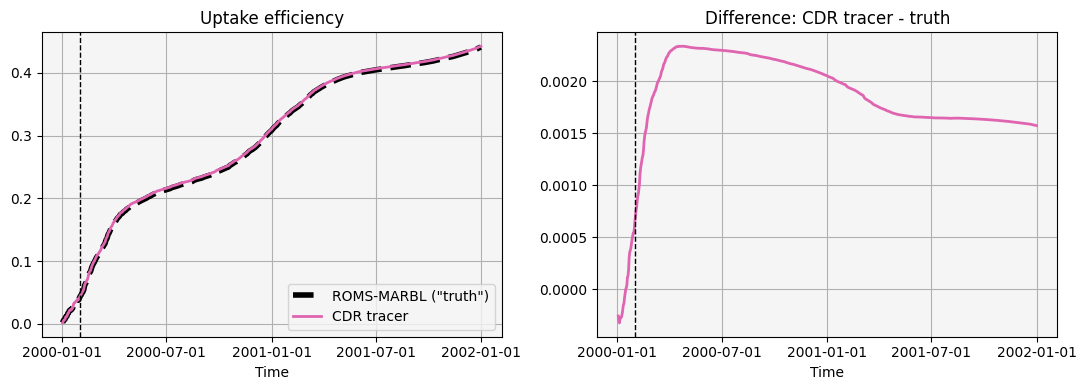

In [50]:
scen = scenarios["dor"]
fig, axs = plt.subplots(1, 2, figsize=(11, 4))
plot_efficiency_curves_single_exp(axs[0], ["JP8"], scen, "dor")
plot_efficiency_curves_diff_pres(axs[1], ["JP8"], scen, "dor", legend=False)
plt.tight_layout()

In [51]:
fig.savefig("figures/eff_Japan.png", dpi=300, bbox_inches="tight")

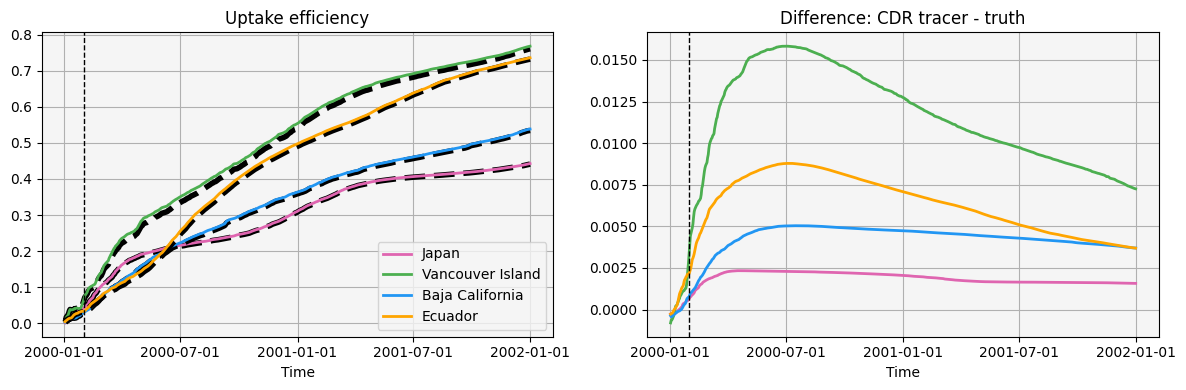

In [52]:
scen = scenarios["dor"]
fig, axs = plt.subplots(1, 2, figsize=(12, 4))
plot_efficiency_curves_single_exp(axs[0], ["JP8", "VI8", "BC8", "EC8"], scen, "dor", minimal_legend=True)
plot_efficiency_curves_diff_pres(axs[1], ["JP8", "VI8", "BC8", "EC8"], scen, "dor", legend=False)
plt.tight_layout()

In [53]:
fig.savefig("figures/eff_all.png", dpi=300, bbox_inches="tight")